In [1]:
# Water Quality Classification using SVM and Random Forest

print("Water Quality Classification Project")
print("Using SVM and Random Forest")

Water Quality Classification Project
Using SVM and Random Forest


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

print("Imports successful!")

Imports successful!


In [5]:
# Duplicate analysis

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after duplicate removal:", df.shape)

Number of duplicate rows: 0
Dataset shape after duplicate removal: (3276, 10)


In [4]:
import pandas as pd

df = pd.read_csv("../data/water_potability.csv")

print(df.head())
print(df.shape)
print(df.isnull().sum())

         ph    Hardness        Solids  Chloramines     Sulfate  Conductivity  \
0       NaN  204.890455  20791.318981     7.300212  368.516441    564.308654   
1  3.716080  129.422921  18630.057858     6.635246         NaN    592.885359   
2  8.099124  224.236259  19909.541732     9.275884         NaN    418.606213   
3  8.316766  214.373394  22018.417441     8.059332  356.886136    363.266516   
4  9.092223  181.101509  17978.986339     6.546600  310.135738    398.410813   

   Organic_carbon  Trihalomethanes  Turbidity  Potability  
0       10.379783        86.990970   2.963135           0  
1       15.180013        56.329076   4.500656           0  
2       16.868637        66.420093   3.055934           0  
3       18.436524       100.341674   4.628771           0  
4       11.558279        31.997993   4.075075           0  
(3276, 10)
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_ca

In [6]:
print(df.describe())

                ph     Hardness        Solids  Chloramines      Sulfate  \
count  2785.000000  3276.000000   3276.000000  3276.000000  2495.000000   
mean      7.080795   196.369496  22014.092526     7.122277   333.775777   
std       1.594320    32.879761   8768.570828     1.583085    41.416840   
min       0.000000    47.432000    320.942611     0.352000   129.000000   
25%       6.093092   176.850538  15666.690297     6.127421   307.699498   
50%       7.036752   196.967627  20927.833607     7.130299   333.073546   
75%       8.062066   216.667456  27332.762127     8.114887   359.950170   
max      14.000000   323.124000  61227.196008    13.127000   481.030642   

       Conductivity  Organic_carbon  Trihalomethanes    Turbidity   Potability  
count   3276.000000     3276.000000      3114.000000  3276.000000  3276.000000  
mean     426.205111       14.284970        66.396293     3.966786     0.390110  
std       80.824064        3.308162        16.175008     0.780382     0.487849  


In [7]:
print(df['Potability'].value_counts())

Potability
0    1998
1    1278
Name: count, dtype: int64


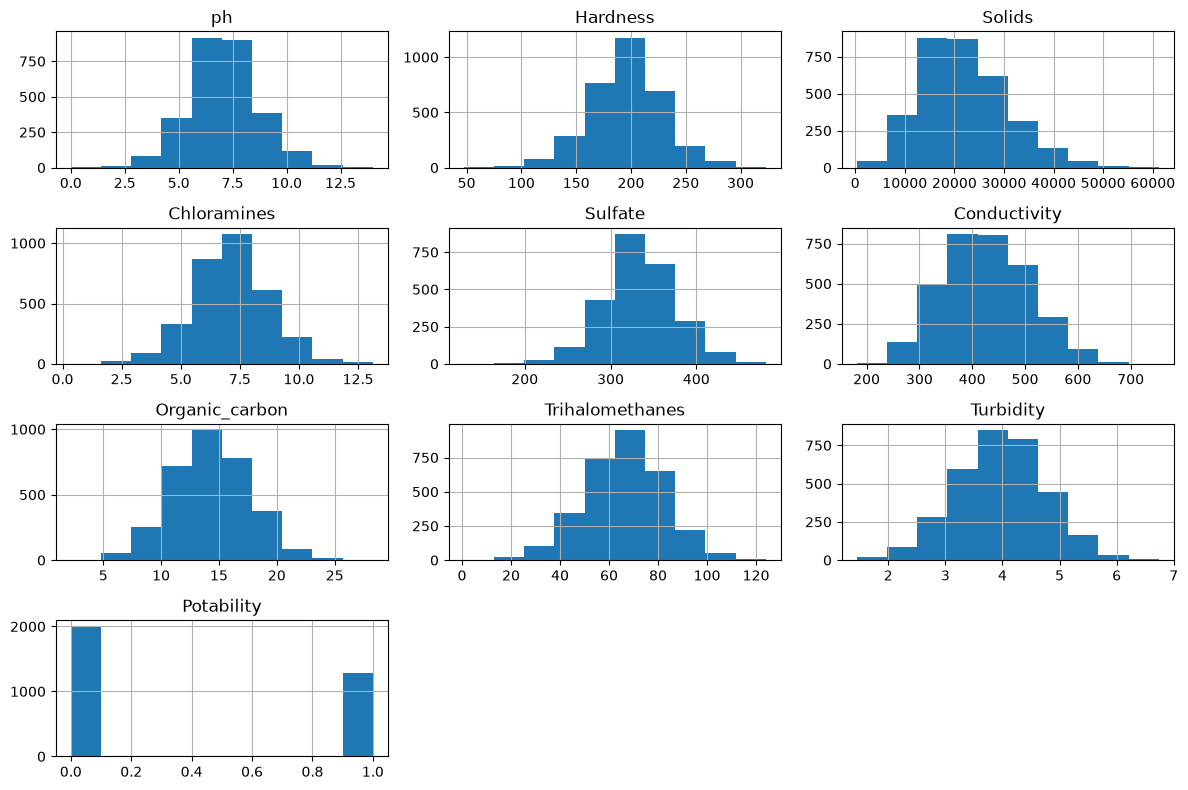

In [8]:
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

In [9]:
print(df.corr())

                       ph  Hardness    Solids  Chloramines   Sulfate  \
ph               1.000000  0.082096 -0.089288    -0.034350  0.018203   
Hardness         0.082096  1.000000 -0.046899    -0.030054 -0.106923   
Solids          -0.089288 -0.046899  1.000000    -0.070148 -0.171804   
Chloramines     -0.034350 -0.030054 -0.070148     1.000000  0.027244   
Sulfate          0.018203 -0.106923 -0.171804     0.027244  1.000000   
Conductivity     0.018614 -0.023915  0.013831    -0.020486 -0.016121   
Organic_carbon   0.043503  0.003610  0.010242    -0.012653  0.030831   
Trihalomethanes  0.003354 -0.013013 -0.009143     0.017084 -0.030274   
Turbidity       -0.039057 -0.014449  0.019546     0.002363 -0.011187   
Potability      -0.003556 -0.013837  0.033743     0.023779 -0.023577   

                 Conductivity  Organic_carbon  Trihalomethanes  Turbidity  \
ph                   0.018614        0.043503         0.003354  -0.039057   
Hardness            -0.023915        0.003610        

In [10]:
X = df.drop('Potability', axis=1)
y = df['Potability']

print("Input features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

Input features:
['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

Target:
Potability


Feature Selection:
The physicochemical parameters were selected as input features, while Potability was used as the target variable. No additional features were created at this stage.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (2620, 9)
Testing data shape: (656, 9)


In [12]:
from sklearn.impute import SimpleImputer

# Create imputer
imputer = SimpleImputer(strategy='median')

# Learn median values ONLY from training data
X_train_imputed = imputer.fit_transform(X_train)

# Apply the same training medians to test data
X_test_imputed = imputer.transform(X_test)

print("Missing values imputed successfully!")
print("Training data shape:", X_train_imputed.shape)
print("Testing data shape:", X_test_imputed.shape)

Missing values imputed successfully!
Training data shape: (2620, 9)
Testing data shape: (656, 9)


In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit scaler ONLY on training data
X_train_scaled = scaler.fit_transform(X_train_imputed)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test_imputed)

print("Scaling completed!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaling completed!
Scaled training data shape: (2620, 9)
Scaled testing data shape: (656, 9)


Data Leakage Prevention:
StandardScaler was fitted only on the training data and then used to transform both training and testing data. The testing data was not used while fitting the scaler, preventing data leakage.

In [14]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel='rbf',
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)

print("SVM model trained successfully!")

SVM model trained successfully!


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [16]:
y_pred_rf = rf_model.predict(X_test_imputed)

print("Random Forest predictions:")
print(y_pred_rf[:10])

Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0]


c:\Users\K. Kavya Sree\Odd sem-2\Machine learning\Placement-Prediction-System\.MLvenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [17]:
# Make predictions using both models

y_pred_svm = svm_model.predict(X_test_scaled)
y_pred_rf = rf_model.predict(X_test)

print("SVM predictions:")
print(y_pred_svm[:10])

print("\nRandom Forest predictions:")
print(y_pred_rf[:10])

SVM predictions:
[0 0 0 0 0 0 0 0 0 0]

Random Forest predictions:
[0 0 0 0 0 0 0 0 0 0]


In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# SVM
print("SVM Results")
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

print("\nRandom Forest Results")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

SVM Results
Accuracy : 0.6707317073170732
Precision: 0.7040816326530612
Recall   : 0.26953125
F1 Score : 0.3898305084745763

Random Forest Results
Accuracy : 0.6615853658536586
Precision: 0.6370967741935484
Recall   : 0.30859375
F1 Score : 0.41578947368421054


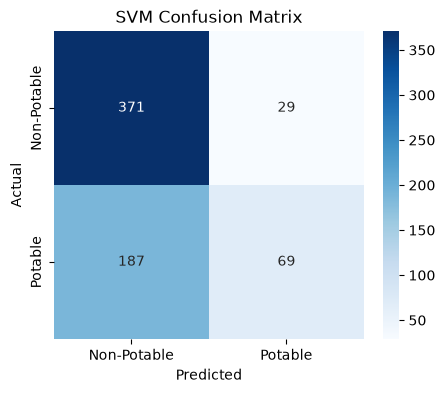

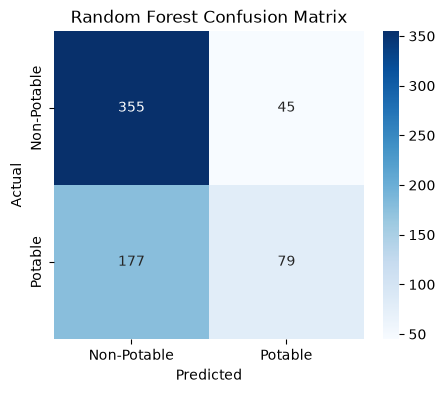

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Potable', 'Potable'],
    yticklabels=['Non-Potable', 'Potable']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('SVM Confusion Matrix')
plt.show()

# Random Forest Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Potable', 'Potable'],
    yticklabels=['Non-Potable', 'Potable']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest Confusion Matrix')
plt.show()

The confusion matrices show the correct and incorrect predictions made by the SVM and Random Forest classifiers for potable and non-potable water samples. The diagonal entries represent correct classifications, while the off-diagonal entries represent misclassifications.

In [20]:
from sklearn.metrics import classification_report

print("SVM Classification Report")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=['Non-Potable', 'Potable']
))

print("\nRandom Forest Classification Report")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=['Non-Potable', 'Potable']
))

SVM Classification Report
              precision    recall  f1-score   support

 Non-Potable       0.66      0.93      0.77       400
     Potable       0.70      0.27      0.39       256

    accuracy                           0.67       656
   macro avg       0.68      0.60      0.58       656
weighted avg       0.68      0.67      0.62       656


Random Forest Classification Report
              precision    recall  f1-score   support

 Non-Potable       0.67      0.89      0.76       400
     Potable       0.64      0.31      0.42       256

    accuracy                           0.66       656
   macro avg       0.65      0.60      0.59       656
weighted avg       0.66      0.66      0.63       656



In [21]:
from sklearn.metrics import roc_auc_score

# Get prediction scores
svm_scores = svm_model.decision_function(X_test_scaled)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC
svm_auc = roc_auc_score(y_test, svm_scores)
rf_auc = roc_auc_score(y_test, rf_prob)

print("SVM ROC-AUC:", svm_auc)
print("Random Forest ROC-AUC:", rf_auc)

SVM ROC-AUC: 0.64875
Random Forest ROC-AUC: 0.663251953125


In [22]:
from sklearn.model_selection import GridSearchCV

svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto']
}

svm_grid = GridSearchCV(
    SVC(kernel='rbf', random_state=42),
    svm_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

svm_grid.fit(X_train_scaled, y_train)

print("Best SVM parameters:")
print(svm_grid.best_params_)

print("Best SVM CV F1-score:")
print(svm_grid.best_score_)

Best SVM parameters:
{'C': 10, 'gamma': 'scale'}
Best SVM CV F1-score:
0.5073579980336935


In [23]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("Best Random Forest CV F1-score:")
print(rf_grid.best_score_)

Best Random Forest parameters:
{'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Best Random Forest CV F1-score:
0.4548844909176088


In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Get the best tuned models
best_svm = svm_grid.best_estimator_
best_rf = rf_grid.best_estimator_

# Predictions using tuned models
y_pred_svm_tuned = best_svm.predict(X_test_scaled)
y_pred_rf_tuned = best_rf.predict(X_test)

# Calculate metrics
print("TUNED SVM RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred_svm_tuned))
print("Precision:", precision_score(y_test, y_pred_svm_tuned))
print("Recall   :", recall_score(y_test, y_pred_svm_tuned))
print("F1 Score :", f1_score(y_test, y_pred_svm_tuned))

print("\nTUNED RANDOM FOREST RESULTS")
print("Accuracy :", accuracy_score(y_test, y_pred_rf_tuned))
print("Precision:", precision_score(y_test, y_pred_rf_tuned))
print("Recall   :", recall_score(y_test, y_pred_rf_tuned))
print("F1 Score :", f1_score(y_test, y_pred_rf_tuned))

TUNED SVM RESULTS
Accuracy : 0.6387195121951219
Precision: 0.5575757575757576
Recall   : 0.359375
F1 Score : 0.43705463182897863

TUNED RANDOM FOREST RESULTS
Accuracy : 0.6692073170731707
Precision: 0.6695652173913044
Recall   : 0.30078125
F1 Score : 0.41509433962264153


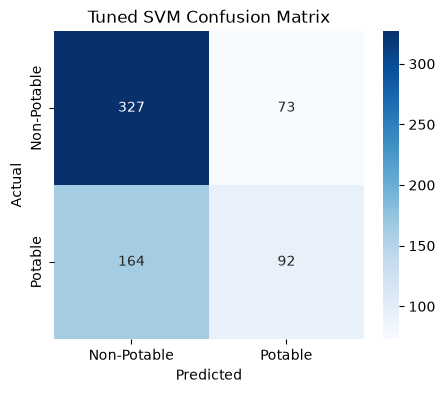

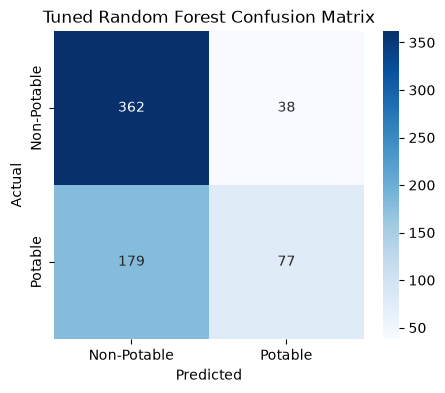

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Tuned SVM confusion matrix
cm_svm_tuned = confusion_matrix(y_test, y_pred_svm_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_svm_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Potable', 'Potable'],
    yticklabels=['Non-Potable', 'Potable']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned SVM Confusion Matrix')
plt.show()


# Tuned Random Forest confusion matrix
cm_rf_tuned = confusion_matrix(y_test, y_pred_rf_tuned)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm_rf_tuned,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Non-Potable', 'Potable'],
    yticklabels=['Non-Potable', 'Potable']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Tuned Random Forest Confusion Matrix')
plt.show()

In [26]:
from sklearn.metrics import classification_report

print("TUNED SVM CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred_svm_tuned,
    target_names=['Non-Potable', 'Potable']
))

print("\nTUNED RANDOM FOREST CLASSIFICATION REPORT")
print(classification_report(
    y_test,
    y_pred_rf_tuned,
    target_names=['Non-Potable', 'Potable']
))

TUNED SVM CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-Potable       0.67      0.82      0.73       400
     Potable       0.56      0.36      0.44       256

    accuracy                           0.64       656
   macro avg       0.61      0.59      0.59       656
weighted avg       0.62      0.64      0.62       656


TUNED RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

 Non-Potable       0.67      0.91      0.77       400
     Potable       0.67      0.30      0.42       256

    accuracy                           0.67       656
   macro avg       0.67      0.60      0.59       656
weighted avg       0.67      0.67      0.63       656



In [27]:
comparison = pd.DataFrame({
    'Model': [
        'SVM (Before Tuning)',
        'SVM (After Tuning)',
        'Random Forest (Before Tuning)',
        'Random Forest (After Tuning)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_svm_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm_tuned),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm_tuned),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm_tuned),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_tuned)
    ]
})

print(comparison.round(3))

                           Model  Accuracy  Precision  Recall  F1 Score
0            SVM (Before Tuning)     0.671      0.704   0.270     0.390
1             SVM (After Tuning)     0.639      0.558   0.359     0.437
2  Random Forest (Before Tuning)     0.662      0.637   0.309     0.416
3   Random Forest (After Tuning)     0.669      0.670   0.301     0.415


In [30]:
svm_tuned_scores = best_svm.decision_function(X_test_scaled)
rf_tuned_prob = best_rf.predict_proba(X_test)[:, 1]

svm_tuned_auc = roc_auc_score(y_test, svm_tuned_scores)
rf_tuned_auc = roc_auc_score(y_test, rf_tuned_prob)

print("SVM Before Tuning ROC-AUC:", svm_auc)
print("SVM After Tuning ROC-AUC:", svm_tuned_auc)
print("Random Forest Before Tuning ROC-AUC:", rf_auc)
print("Random Forest After Tuning ROC-AUC:", rf_tuned_auc)

SVM Before Tuning ROC-AUC: 0.64875
SVM After Tuning ROC-AUC: 0.630341796875
Random Forest Before Tuning ROC-AUC: 0.663251953125
Random Forest After Tuning ROC-AUC: 0.6668164062499999


## Final Model Selection

The tuned SVM was selected as the final model because it achieved a higher F1-score and higher recall for the potable-water class compared with the tuned Random Forest model. Since identifying potable water correctly is important for this classification task, recall and F1-score were given importance along with overall accuracy and ROC-AUC.

In [39]:
# Final prediction using the selected tuned SVM model

sample = X_test.iloc[[0]]

# Handle missing values using the fitted imputer
sample_imputed = imputer.transform(sample)

# Scale using the fitted scaler
sample_scaled = scaler.transform(sample_imputed)

# Make prediction
prediction = best_svm.predict(sample_scaled)[0]

print("Sample input:")
print(sample)

print("\nPredicted output:")

if prediction == 1:
    print("Potable")
else:
    print("Non-Potable")

Sample input:
     ph    Hardness        Solids  Chloramines  Sulfate  Conductivity  \
664 NaN  188.743562  19037.462638     6.034236      NaN    388.065857   

     Organic_carbon  Trihalomethanes  Turbidity  
664       15.149068        78.499418   2.723651  

Predicted output:
Non-Potable


In [40]:
print("Actual value:", y_test.iloc[0])
print("Predicted value:", prediction)

Actual value: 1
Predicted value: 0


In [33]:
print("Final dataset shape:", df.shape)

print("\nMissing values:")
print(df.isnull().sum())

print("\nData types:")
print(df.dtypes)

Final dataset shape: (3276, 10)

Missing values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Data types:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object


### Final Preprocessing Results

After preprocessing, the dataset contains 3276 records and 10 columns, consisting of 9 input features and 1 target variable.

### Feature Selection

The target variable is Potability. All nine water-quality measurements were selected as input features because they represent different physical and chemical properties of the water and may contribute to predicting potability.

Final features used for modelling:

- ph
- Hardness
- Solids
- Chloramines
- Sulfate
- Conductivity
- Organic_carbon
- Trihalomethanes
- Turbidity

Target variable: Potability

In [36]:
comparison = pd.DataFrame({
    'Model': [
        'SVM Before Tuning',
        'SVM After Tuning',
        'Random Forest Before Tuning',
        'Random Forest After Tuning'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_svm_tuned),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_rf_tuned)
    ],
    'Precision': [
        precision_score(y_test, y_pred_svm),
        precision_score(y_test, y_pred_svm_tuned),
        precision_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf_tuned)
    ],
    'Recall': [
        recall_score(y_test, y_pred_svm),
        recall_score(y_test, y_pred_svm_tuned),
        recall_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf_tuned)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_svm),
        f1_score(y_test, y_pred_svm_tuned),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf_tuned)
    ]
})

comparison.round(3)

,Model,Accuracy,Precision,Recall,F1 Score
0,SVM Before Tuning,0.671,0.704,0.270,0.390
1,SVM After Tuning,0.639,0.558,0.359,0.437
2,Random Forest Before Tuning,0.662,0.637,0.309,0.416
3,Random Forest After Tuning,0.669,0.670,0.301,0.415


## Model Comparison

The models were compared using accuracy, precision, recall, and F1-score. The tuned SVM achieved the highest F1-score among the tuned models, while the tuned Random Forest achieved the highest ROC-AUC. The tuned SVM was selected as the final model because recall and F1-score for the potable class were given greater importance.

## Conclusion

This project developed a machine learning classification system to predict water potability using water-quality parameters. The dataset was preprocessed by handling missing values, checking duplicate records, and applying feature scaling where required.

Two classification algorithms, Support Vector Machine (SVM) and Random Forest, were implemented and evaluated using accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.

Hyperparameter tuning was performed using GridSearchCV to improve model performance. The tuned SVM achieved an F1-score of approximately 0.437, while the tuned Random Forest achieved an F1-score of approximately 0.413.

The tuned SVM was selected as the final model because it provided better recall and F1-score for the potable-water class. However, the overall performance indicates that water potability is a challenging classification problem and that additional features or more advanced modelling techniques could potentially improve prediction performance.

The final model was also demonstrated on an unseen test sample to show how the system predicts whether a water sample is potable or non-potable.

## Project Summary

### Problem
Predict whether a water sample is potable or non-potable based on its water-quality measurements.

### Dataset
Water Potability Dataset

### Input Features
9 water-quality features

### Target
Potability

### Models
- Support Vector Machine (SVM)
- Random Forest Classifier

### Final Model
Tuned SVM

### Best F1-score
0.437

### Final Demonstration
The selected model was used to predict the class of an unseen test sample.